# Data Retrieval 

In [1]:
import pandas as pd

permit_df = pd.read_csv("input_data/DOB_Permit_Issuance_20250508.csv", dtype=str)

# Data Clean Up

In [4]:
print(permit_df.head())
print("Columns: ", list(permit_df.columns))
print("Number of rows: ", len(permit_df))

         BOROUGH    Bin # House #       Street Name      Job # Job doc. #  \
0      MANHATTAN  1088749       1       MADISON AVE  141008987         01   
1  STATEN ISLAND  5076937      87     BOYLAN STREET  540218539         01   
2  STATEN ISLAND  5001506     217  LAFAYETTE AVENUE  540218575         01   
3  STATEN ISLAND  5067021     170    OAKDALE STREET  540218600         01   
4  STATEN ISLAND  5058036     273         10 STREET  540218628         01   

  Job Type Self_Cert  Block    Lot  ... Owner’s House State  \
0       A3         Y  00853  00002  ...                 NaN   
1       A2         Y  05687  00066  ...                 NaN   
2       A2         Y  00064  00022  ...                 NaN   
3       A2         Y  05260  00001  ...                 NaN   
4       A2         Y  04242  00045  ...                 NaN   

  Owner’s House Zip Code Owner's Phone #           DOBRunDate PERMIT_SI_NO  \
0                    NaN      2125942700  05/11/2022 00:00:00      3905851   
1 

In [5]:
# Check for duplicates by checking each row identifier
permit_df = permit_df.drop_duplicates(subset=["PERMIT_SI_NO"])
print("Number of rows after removing duplicates: ", len(permit_df))

Number of rows after removing duplicates:  3978666


In [6]:
# view null value counts in the data
num_null_col = permit_df.isnull().sum()
print("Number of null values per column")
print(num_null_col)

Number of null values per column
BOROUGH                                   0
Bin #                                     0
House #                                   4
Street Name                               4
Job #                                     0
Job doc. #                                0
Job Type                                  0
Self_Cert                           1337178
Block                                   497
Lot                                     506
Community Board                        1587
Zip Code                               1256
Bldg Type                             57399
Residential                         2358005
Special District 1                  3522307
Special District 2                  3978075
Work Type                            720011
Permit Status                         11228
Filing Status                             0
Permit Type                               1
Permit Sequence #                         0
Permit Subtype                      1577518

In [7]:
# view null percentages in the data
percent_null_col = (num_null_col / len(permit_df)) * 100
print("Percent of null values per column")
print(percent_null_col)

Percent of null values per column
BOROUGH                              0.000000
Bin #                                0.000000
House #                              0.000101
Street Name                          0.000101
Job #                                0.000000
Job doc. #                           0.000000
Job Type                             0.000000
Self_Cert                           33.608702
Block                                0.012492
Lot                                  0.012718
Community Board                      0.039888
Zip Code                             0.031568
Bldg Type                            1.442669
Residential                         59.266221
Special District 1                  88.529849
Special District 2                  99.985146
Work Type                           18.096794
Permit Status                        0.282205
Filing Status                        0.000000
Permit Type                          0.000025
Permit Sequence #                    0.000000


In [41]:
# dropping columns with over 90% missing values to help with performance
drop_cols = percent_null_col[percent_null_col > 90].index
permit_df_dropped = permit_df.drop(columns=drop_cols)

In [63]:
# get formatting for Filing Date
print(set(permit_df_dropped["Filing Date"]))
# value counts
print(permit_df_dropped[["Filing Date"]].value_counts(dropna=False).head())
print()

# Filing Date seems to granular according to value counts --> getting month/year and year
def get_month_year(date):
    if len(date.split("/")) == 3:
        return f'{date.split("/")[0]}/{date.split("/")[2]}'
    elif len(date.split("-")) == 3:
        return f'{date.split("-")[1]}/{date.split("-")[0]}'
    
def get_year(date):
    if len(date.split("/")) == 3:
        return date.split("/")[2]
    elif len(date.split("-")) == 3:
        return date.split("-")[0]

permit_df_dropped["Filing Date"] = permit_df_dropped["Filing Date"].fillna("")
permit_df_dropped["Filing Date Month/Year"] = permit_df_dropped["Filing Date"].apply(get_month_year)
permit_df_dropped["Filing Date Year"] = permit_df_dropped["Filing Date"].apply(get_year)

# checking value counts
print(permit_df_dropped[["Filing Date Month/Year"]].value_counts(dropna=False).head())
print(permit_df_dropped[["Filing Date Year"]].value_counts(dropna=False).head())

print(permit_df_dropped["Filing Date Month/Year"].head())
print(permit_df_dropped["Filing Date Year"].head())

{'', '04/30/1998', '2000-06-20 ', '2012-12-21 ', '2006-12-29 ', '01/25/2011', '2002-09-12 ', '12/16/2017', '04/10/2006', '1989-11-16 ', '06/29/2014', '05/16/2017', '11/01/1999', '03/11/2009', '2010-12-02 ', '2017-11-03 ', '05/06/2010', '2018-05-31 ', '2011-09-22 ', '10/24/1995', '2011-10-27 ', '01/21/2019', '1994-11-14 ', '2000-04-20 ', '03/25/2003', '2016-09-21 ', '1994-09-14 ', '04/13/2008', '10/29/2020', '06/22/1999', '2010-08-02 ', '01/26/2001', '04/07/2018', '2007-05-10 ', '12/02/1994', '06/01/2010', '06/02/1999', '12/19/2014', '01/06/2025', '2018-08-27 ', '07/17/2022', '1997-02-21 ', '12/16/2020', '02/27/2025', '2012-07-17 ', '2012-06-25 ', '08/19/2013', '2007-09-20 ', '2018-01-29 ', '08/02/2021', '2017-02-09 ', '02/16/2000', '05/05/2010', '2012-07-06 ', '06/11/2001', '07/02/1992', '05/28/1998', '12/16/1999', '09/18/2008', '05/14/2006', '09/18/2004', '2019-12-11 ', '05/31/2006', '12/02/1991', '2010-12-09 ', '1995-04-14 ', '05/05/2000', '03/25/2011', '06/21/2011', '09/12/2009', '0

# Analysis

In [64]:
# filtering down to columns for analysis (based on data mentioned in documentation and column descriptions)
permit_df_filtered = permit_df_dropped[["PERMIT_SI_NO", "Job Type", "Work Type", "Permit Type", "Permit Subtype", "Permit Status", "LATITUDE", "LONGITUDE", "COUNCIL_DISTRICT", "CENSUS_TRACT", "Filing Status", "Bldg Type", "Zip Code", "BOROUGH", "Filing Date Month/Year", "Filing Date Year"]]

In [80]:
# initial look into value counts for each column (ie number of inque values)
    # excluding non-categorical and id data
summary_table = permit_df_filtered.drop(columns=["PERMIT_SI_NO", "LONGITUDE", "LATITUDE"]).describe()
summary_table.T.to_csv("output_data/permit_summary_table.csv")
print(summary_table)

           Filing Date Year datetime Filing Date Month/Year datetime
count                        3978665                         3978665
mean   2008-06-25 21:14:59.276818432   2008-12-09 13:14:15.707631360
min              1989-01-01 00:00:00             1989-05-01 00:00:00
25%              2002-01-01 00:00:00             2002-12-01 00:00:00
50%              2009-01-01 00:00:00             2009-08-01 00:00:00
75%              2015-01-01 00:00:00             2015-12-01 00:00:00
max              2025-01-01 00:00:00             2025-05-01 00:00:00


In [90]:
import matplotlib.pyplot as plt

def create_freq_graph(percentages, title, x_label, y_label, save=False):
    bars = plt.bar(percentages.index, percentages.values)

    # Customize the plot
    plt.xlabel(x_label)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(y_label)
    plt.title(title)
    plt.ylim(0, 100) 
    # plt.grid(axis='y', linestyle='--')
    if save:
        plt.savefig(f'output_data/{"_".join(title.split(" "))}.png', dpi=300, bbox_inches='tight')
    plt.show()


Job Type Job Type
A2    2384010
NB     568797
A1     432372
A3     413266
DM     102211
SG      78010
Name: count, dtype: int64


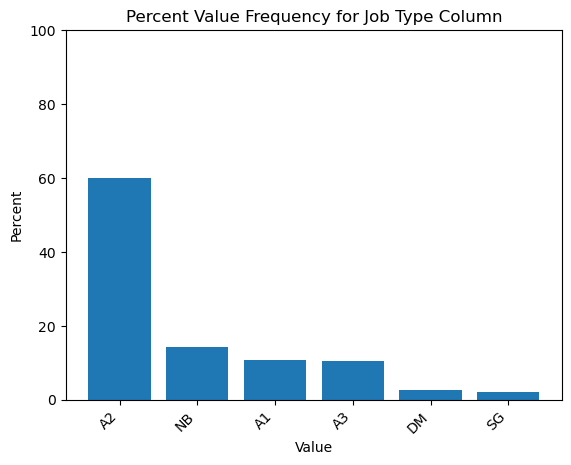


Work Type Work Type
OT     1171409
PL      780436
NaN     720011
EQ      577538
MH      348482
SP      139918
BL       75288
FP       65029
FB       41330
FS       24343
SD       22849
CC       11766
FA         266
NB           1
Name: count, dtype: int64


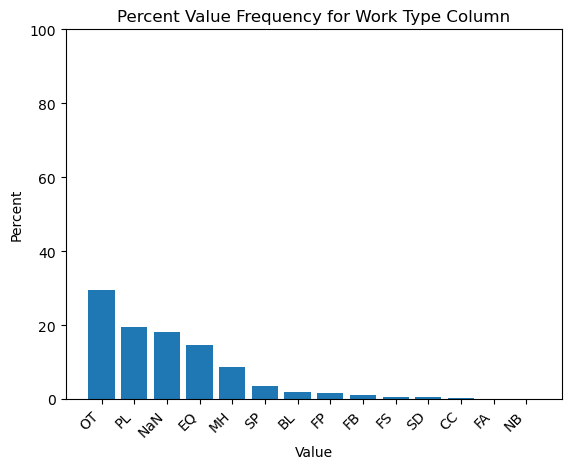


Permit Type Permit Type
EW     1790595
PL      780435
EQ      577538
AL      359820
NB      265343
SG       77990
FO       67454
DM       59490
NaN          1
Name: count, dtype: int64


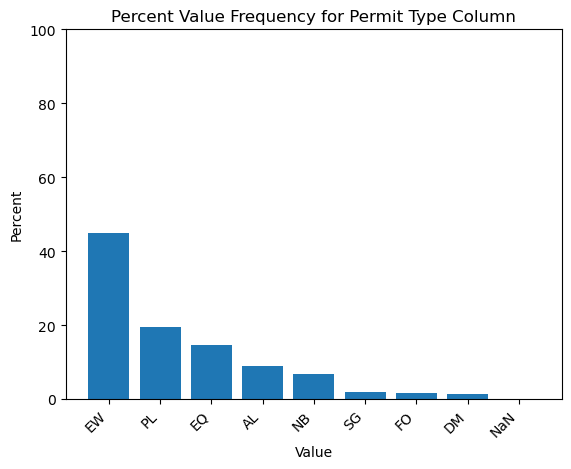


Permit Subtype Permit Subtype
NaN    1577518
OT     1107223
MH      348482
FN      307636
SH      179815
SP      139918
BL       75288
FP       65029
SF       53963
FB       41330
EA       33014
FS       24343
SD       22849
CH        1990
FA         266
SC           2
Name: count, dtype: int64


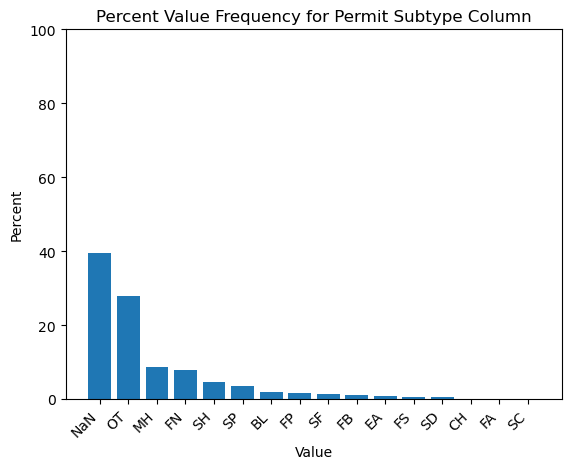


Filing Status Filing Status
INITIAL    2795889
RENEWAL    1182777
Name: count, dtype: int64


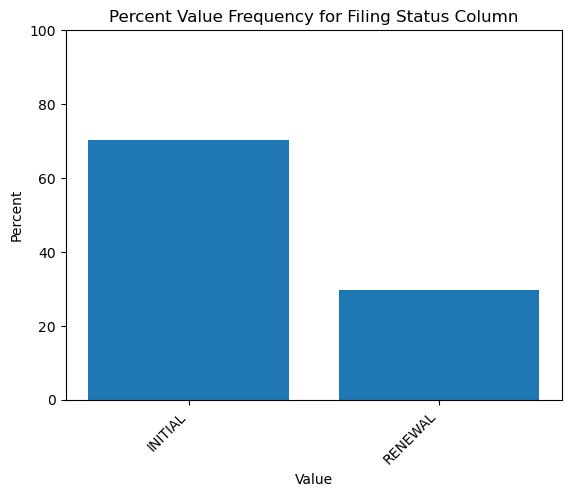


Permit Status Permit Status
ISSUED        3897727
RE-ISSUED       48818
IN PROCESS      20888
NaN             11228
REVOKED             5
Name: count, dtype: int64


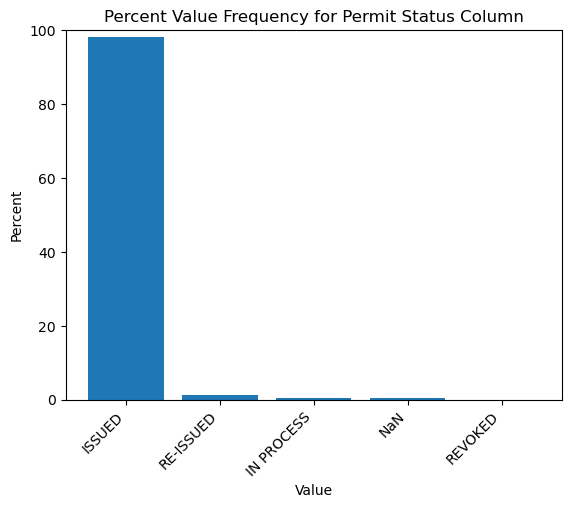

In [46]:
# most frequent values for highlighted columns in the data description
for col in ["Job Type", "Work Type", "Permit Type", "Permit Subtype", "Filing Status", "Permit Status"]:
    value_counts = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False)
    percentages = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False, normalize=True)  * 100
    print(col, value_counts)
    create_freq_graph(percentages, f'Percent Value Frequency for {col} Column', 'Value', 'Percent')
    print()

In [47]:
# counts of combinations from permit and job-related columns and the frequency of each column
print('Value counts for "Job Type", "Work Type", "Permit Type", "Permit Subtype"')
print(permit_df_filtered[["Job Type", "Work Type", "Permit Type", "Permit Subtype"]].value_counts(dropna=False))
print()
print('Percentages for "Job Type", "Work Type", "Permit Type", "Permit Subtype"')
print((permit_df_filtered[["Job Type", "Work Type", "Permit Type", "Permit Subtype"]].value_counts(dropna=False, normalize=True) * 100).head())

Value counts for "Job Type", "Work Type", "Permit Type", "Permit Subtype"
Job Type  Work Type  Permit Type  Permit Subtype
A2        OT         EW           OT                1073089
          PL         PL           NaN                524891
          MH         EW           MH                 348482
NB        NaN        NB           NaN                265341
A1        NaN        AL           NaN                239029
                                                     ...   
NB        OT         NB           NaN                     1
A2        OT         EW           NaN                     1
A1        PL         NaN          NaN                     1
A3        NaN        FO           EA                      1
A2        NaN        AL           NaN                     1
Name: count, Length: 66, dtype: int64

Percentages for "Job Type", "Work Type", "Permit Type", "Permit Subtype"
Job Type  Work Type  Permit Type  Permit Subtype
A2        OT         EW           OT                26.9

BOROUGH BOROUGH
MANHATTAN        1621373
BROOKLYN          943632
QUEENS            838648
BRONX             342729
STATEN ISLAND     232284
Name: count, dtype: int64


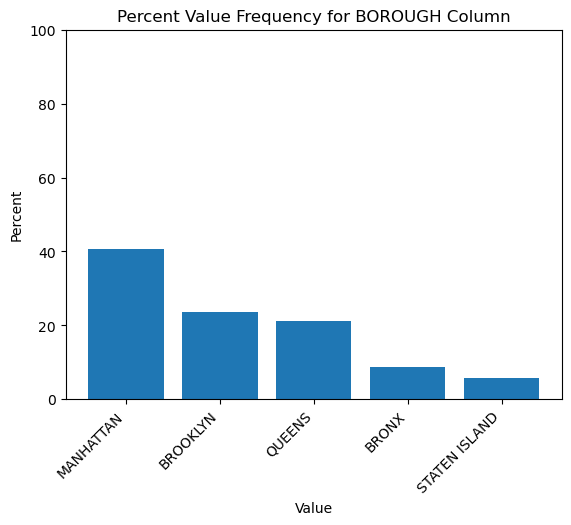


Bldg Type Bldg Type
2      2951226
1       970041
NaN      57399
Name: count, dtype: int64


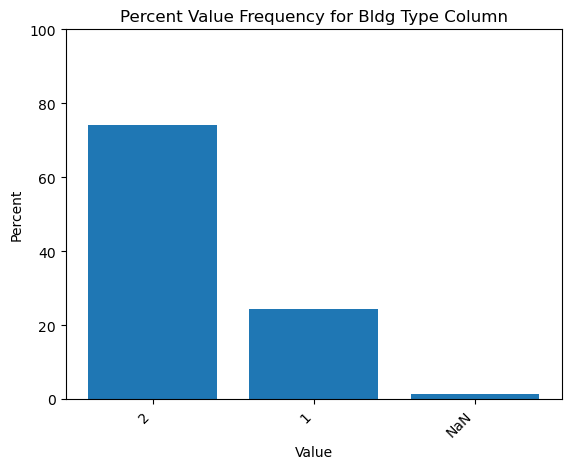


Filing Date Year Filing Date Year
2017    198059
2016    193583
2015    184917
2018    177657
2014    172806
2013    163082
2007    161178
2006    160511
2019    156159
2005    154658
2008    153412
2012    150355
2011    145464
2004    144427
2010    138007
2009    137397
2003    128767
2002    118150
2001    108864
2000    106272
1999     94704
2020     93543
1998     85536
1997     75889
1996     72090
2021     69091
1995     67737
1994     65621
1993     62504
1992     57428
1991     50989
2022     46568
2023     33090
1990     27318
2024     14598
2025      4551
1989      3683
NaN          1
Name: count, dtype: int64


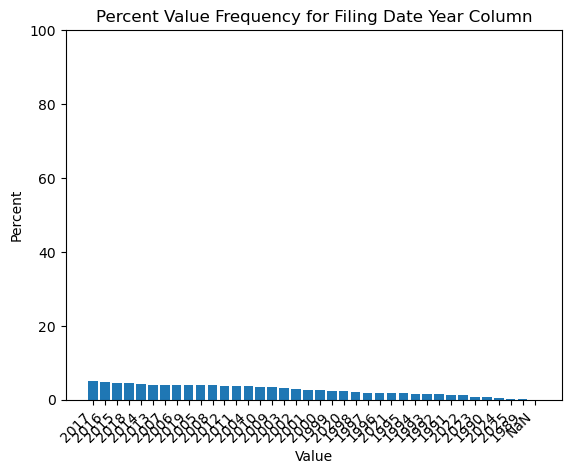

In [65]:
# value counts for other interesting columns
for col in ["BOROUGH", "Bldg Type", "Filing Date Year"]:
    value_counts = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False)
    percentages = permit_df_filtered[col].fillna("NaN").value_counts(dropna=False, normalize=True)  * 100
    print(col, value_counts)
    create_freq_graph(percentages, f'Percent Value Frequency for {col} Column', 'Value', 'Percent')
    print()

/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/1377751346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  permit_df_filtered['Filing Date Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Year'])


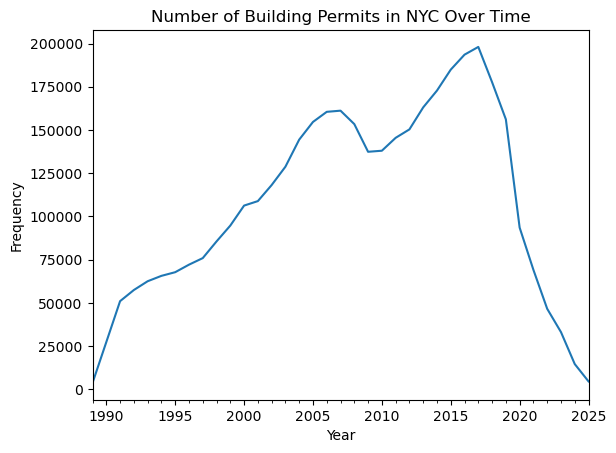

In [78]:
permit_df_filtered['Filing Date Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Year'])
value_counts = permit_df_filtered['Filing Date Year datetime'].value_counts().sort_index()
value_counts.plot(kind='line')
    
# Customize the plot (optional)
plt.title('Number of Building Permits in NYC Over Time')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.savefig('output_data/building_permit_freq_over_time.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/665316006.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  permit_df_filtered['Filing Date Month/Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Month/Year'])
/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/665316006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  permit_df_filtered['Filing Date Month/Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Month/Year'])


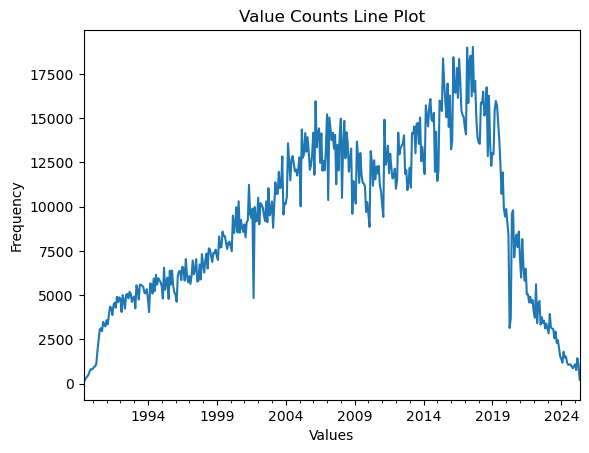

In [ ]:
permit_df_filtered['Filing Date Month/Year datetime'] = pd.to_datetime(permit_df_filtered['Filing Date Month/Year'])
value_counts = permit_df_filtered['Filing Date Month/Year datetime'].value_counts().sort_index()
value_counts.plot(kind='line')
    
# Customize the plot (optional)
plt.title('Number of Building Permits Over Time')
plt.xlabel('Month/Year')
plt.ylabel('Frequency')

# Display the plot
plt.show()

# Processing and cleaning historic districts

In [51]:
# getting data
historic_df = pd.read_csv("input_data/Historic_Districts_20250508.csv", dtype=str)

In [52]:
print(historic_df.head())
print()
print("Columns: ", list(historic_df.columns))
print()
print("Number of rows: ", len(historic_df))
print()
print(historic_df.describe())

                                            the_geom BOROUGH LP_NUMBER  \
0  MULTIPOLYGON (((-73.78070476564865 40.79368791...      QN  LP-02040   
1  MULTIPOLYGON (((-73.9545180987722 40.781621828...      MN  LP-01985   
2  MULTIPOLYGON (((-73.9944118740248 40.725865366...      MN  LP-02287   
3  MULTIPOLYGON (((-73.95607477556511 40.67451198...      BK  LP-02446   
4  MULTIPOLYGON (((-73.98858964616774 40.73001207...      MN  LP-00250   

  CURRENT_                                  AREA_NAME EXTENSION  STATUS_OF_  \
0      Yes              Fort Totten Historic District        No  DESIGNATED   
1      Yes  Hardenbergh/Rhinelander Historic District        No  DESIGNATED   
2      Yes           NoHo Historic District Extension       Yes  DESIGNATED   
3      Yes               Park Place Historic District        No  DESIGNATED   
4      Yes               St. Mark's Historic District        No  DESIGNATED   

   LAST_ACTIO BOUNDARY_N  PUBLIC_HEA OTHER_HEAR     DESDATE     CALDATE  \
0  DE

In [53]:
# creating geodataframe
import shapely
import geopandas as gpd

historic_df['the_geom'] = historic_df['the_geom'].apply(shapely.wkt.loads)
historic_gdf = gpd.GeoDataFrame(historic_df, geometry='the_geom', crs="EPSG:4326")


In [68]:
geometry = gpd.points_from_xy(permit_df_filtered["LONGITUDE"], permit_df_filtered["LATITUDE"], crs="EPSG:4326")
permit_df_filtered["permit_geometry"] = geometry
permit_gdf = gpd.GeoDataFrame(permit_df_filtered, geometry='permit_geometry')


/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/3878302790.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  permit_df_filtered["permit_geometry"] = geometry


In [69]:
merged_df = gpd.sjoin(permit_gdf, historic_gdf, how='left', predicate="within")
merged_df["AREA_NAME"] = merged_df["AREA_NAME"].fillna("Not in historic district")
print("merged_df columns: ", merged_df.columns)

merged_df columns:  Index(['PERMIT_SI_NO', 'Job Type', 'Work Type', 'Permit Type',
       'Permit Subtype', 'Permit Status', 'LATITUDE', 'LONGITUDE',
       'COUNCIL_DISTRICT', 'CENSUS_TRACT', 'Filing Status', 'Bldg Type',
       'Zip Code', 'BOROUGH_left', 'Filing Date Month/Year',
       'Filing Date Year', 'Filing Date Year datetime',
       'Filing Date Month/Year datetime', 'permit_geometry', 'index_right',
       'BOROUGH_right', 'LP_NUMBER', 'CURRENT_', 'AREA_NAME', 'EXTENSION',
       'STATUS_OF_', 'LAST_ACTIO', 'BOUNDARY_N', 'PUBLIC_HEA', 'OTHER_HEAR',
       'DESDATE', 'CALDATE', 'Shape_Leng', 'Shape_Area'],
      dtype='object')


In [70]:
area_value_counts = merged_df["AREA_NAME"].value_counts(dropna=False)
area_percentage = merged_df["AREA_NAME"].value_counts(dropna=False, normalize=True) * 100
print(area_value_counts)
print()
print(area_percentage)

AREA_NAME
Not in historic district                               3583682
Greenwich Village Historic District                      42048
Upper East Side Historic District                        39238
Upper West Side/Central Park West Historic District      35529
SoHo-Cast Iron Historic District                         25504
                                                        ...   
Linden Street Historic District                             11
Sunset Park North Historic District                         10
Cambria Heights-227th Street Historic District               9
Chester Court Historic District                              4
Melrose Parkside Historic District                           3
Name: count, Length: 142, dtype: int64

AREA_NAME
Not in historic district                               90.033077
Greenwich Village Historic District                     1.056375
Upper East Side Historic District                       0.985779
Upper West Side/Central Park West Historic District 

AREA_NAME
Greenwich Village Historic District                    42048
Upper East Side Historic District                      39238
Upper West Side/Central Park West Historic District    35529
SoHo-Cast Iron Historic District                       25504
Ladies' Mile Historic District                         24361
                                                       ...  
Linden Street Historic District                           11
Sunset Park North Historic District                       10
Cambria Heights-227th Street Historic District             9
Chester Court Historic District                            4
Melrose Parkside Historic District                         3
Name: count, Length: 141, dtype: int64

AREA_NAME
Greenwich Village Historic District                      10.598804
Upper East Side Historic District                         9.890503
Upper West Side/Central Park West Historic District       8.955596
SoHo-Cast Iron Historic District                          6.428651
L

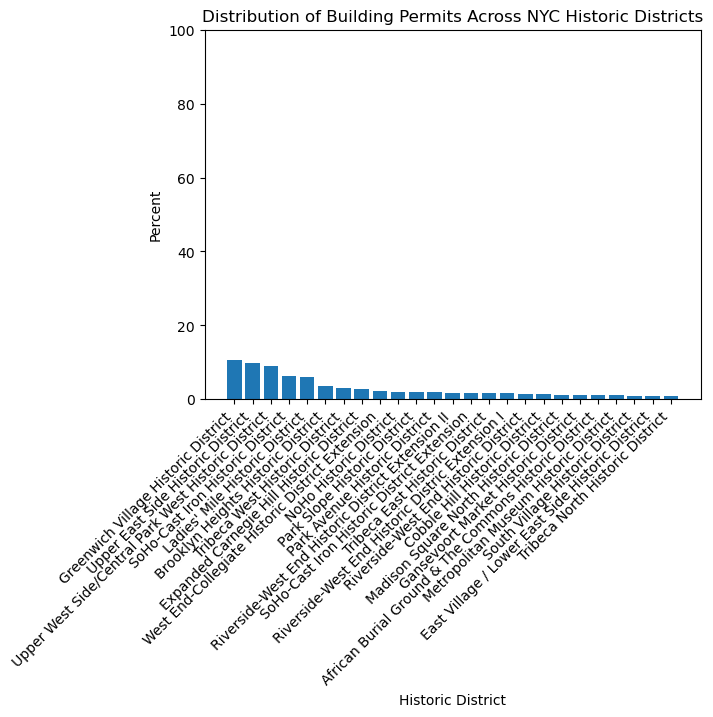

In [91]:
area_value_counts = merged_df[merged_df["AREA_NAME"] != "Not in historic district"]["AREA_NAME"].value_counts(dropna=False)
area_percentage = merged_df[merged_df["AREA_NAME"] != "Not in historic district"]["AREA_NAME"].value_counts(dropna=False, normalize=True) * 100
print(area_value_counts)
print()
print(area_percentage[area_percentage > 1])
create_freq_graph(area_percentage[area_percentage > 1], "Distribution of Building Permits Across NYC Historic Districts", "Historic District", "Percent", save=True)

In [72]:
# Historic districts that don't have any building permits in them
print(historic_gdf[~historic_gdf["AREA_NAME"].isin(area_percentage.index)]["AREA_NAME"])

1              Hardenbergh/Rhinelander Historic District
3                           Park Place Historic District
9                      Audubon Terrace Historic District
33           Douglaston Hill Historic District Amendment
36               Fraunces Tavern Block Historic District
39                    East 10th Street Historic District
40     East 17th Street / Irving Place Historic District
57                       Hunters Point Historic District
60                     Lamartine Place Historic District
78                        Perry Avenue Historic District
86      South Street Seaport Historic District Extension
96                  Turtle Bay Gardens Historic District
100    Central Park West - West 73rd - 74th Street Hi...
115                  Ocean on the Park Historic District
128            Gramercy Park Historic District Extension
132                       Ellis Island Historic District
Name: AREA_NAME, dtype: object


In [79]:
# summary stats for building permits in historical districts
merged_df_summary_table = merged_df[merged_df["AREA_NAME"] != "Not in historic district"][['Job Type', 'Work Type', 'Permit Type', 'Permit Subtype', 'Permit Status', 'Bldg Type', 'BOROUGH_left', 'AREA_NAME', 'Filing Date Month/Year', 'Filing Date Year']].describe()
merged_df_summary_table.T.to_csv("output_data/historic_permit_summary_table.csv")
print(merged_df_summary_table)

       Job Type Work Type Permit Type Permit Subtype Permit Status Bldg Type  \
count    396724    362717      396723         275506        396222    395280   
unique        6        12           8             14             3         2   
top          A2        OT          EW             OT        ISSUED         2   
freq     297476    148662      222335         146336        389624    350921   

       BOROUGH_left                            AREA_NAME  \
count        396724                               396724   
unique            5                                  141   
top       MANHATTAN  Greenwich Village Historic District   
freq         326028                                42048   

       Filing Date Month/Year Filing Date Year  
count                  396724           396724  
unique                    432               37  
top                   08/2016             2016  
freq                     2175            21040  


In [83]:
merged_df = merged_df[['PERMIT_SI_NO', 'Job Type', 'Work Type', 'Permit Type',
       'Permit Subtype', 'Permit Status', 'LATITUDE', 'LONGITUDE',
       'COUNCIL_DISTRICT', 'CENSUS_TRACT', 'Filing Status', 'Bldg Type',
       'Zip Code', 'BOROUGH_left', 'Filing Date Month/Year',
       'Filing Date Year', 'permit_geometry', 'AREA_NAME']]

merged_df = merged_df.rename(columns={"BOROUGH_left": "BOROUGH"})

In [86]:
merged_df.to_csv("output_data/cleaned_dob_permit_issuance.csv", index=False)

In [89]:
merged_df.to_file("output_data/shapes/permit_issuance.shp")

/var/folders/ds/dbv3h1h93pjgyk54lfs80x4w0000gn/T/ipykernel_12801/1746143904.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_df.to_file("output_data/shapes/permit_issuance.shp")
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'PERMIT_SI_NO' to 'PERMIT_SI_'
  ogr_write(
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Permit Type' to 'Permit Typ'
  ogr_write(
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Permit Subtype' to 'Permit Sub'
  ogr_write(
/Users/jasmine/miniconda3/envs/conda-env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Permit Status' to 'Permit Sta'
  ogr_write(
/Users/jasmine/minicon